# Ecuación de onda y cuerda real

$\rho(x) = $

dt = 0.0000 s


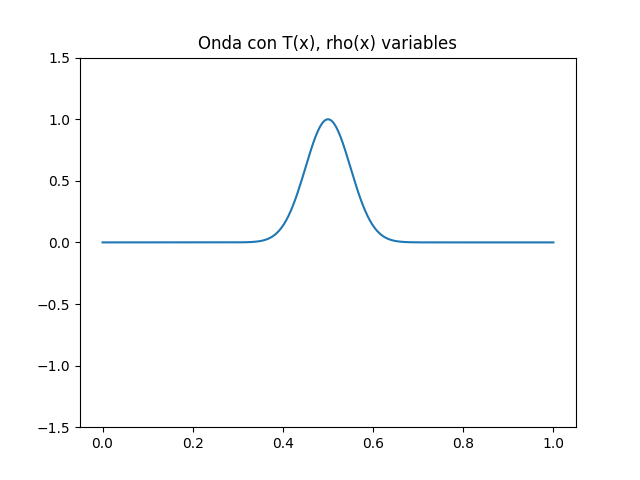

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

L = 1.0
nx = 200
dx = L / (nx - 1)

# Parámetros
alpha = 0.5
rho0 = 0.01
T0 = 40.0
kappa = 0.0

# Malla
x = np.linspace(0, L, nx)

# Modelos
modelo = "exponencial" # "catenaria"

if modelo == "exponencial":
    rho = rho0 * np.exp(alpha * x)
    T = T0 * np.exp(alpha * x)
elif modelo == "catenaria":
    g = 9.8
    rho = rho0 * np.ones_like(x)
    T = T0 * np.cosh(rho0*g*x/T0)

v = np.sqrt(T / rho)
vmax = np.max(v)

# Condiciones iniciales
dt = 0.4*dx/vmax

print(f"dt = {dt:.4f} s")

y = np.exp(-200*(x-0.5)**2) # Pulso gaussiano
y_old = np.copy(y)
y_new = np.zeros(nx)

def step():
    global y, y_old, y_new
    for i in range(1, nx-1):
        T_ip = 0.5 * (T[i] + T[i+1])
        T_im = 0.5 * (T[i] + T[i-1])

        lap = (T_ip * (y[i+1] - y[i]) - T_im * (y[i] - y[i-1])) / dx**2

        y_new[i] = (2*y[i] - y_old[i] + dt**2 * lap / rho[i] - kappa * dt * (y[i] - y_old[i]))

    y_new[0] = 0.0
    y_new[-1] = 0.0

    y_old[:] = y[:]
    y[:] = y_new[:]

# Graficar

fig, ax = plt.subplots()
line, = ax.plot(x, y)

ax.set_ylim(-1.5, 1.5)
ax.set_title("Onda con T(x), rho(x) variables")

def update(frame):
    for _ in range(5):  # Avanzar varias veces por frame para suavizar la animación
        step()
    line.set_ydata(y)
    return line,

ani = FuncAnimation(fig, update, frames=1000, interval = 20)
plt.show()